# Climate Risk Assessment with CRTB

This tutorial demonstrates how to use the FAO **Climate Risk Toolbox (CRTB)** process to assess climate-related hazards, vulnerability, exposure, and adaptive capacity for any region of interest.

The CRTB is a FAO-specific process that analyzes multiple climate risk indicators simultaneously, classifying each into risk levels (Low, Moderate, High, Very High).

**What you will learn:**
- How to run a Hazards Baseline assessment
- How to interpret risk classification results
- How to compare different climate scenarios (RCP 2.6 vs RCP 8.5)
- How to assess Vulnerability, Exposure, and Adaptive Capacity
- How to use GEE Feature Collections for administrative boundaries
- How to visualize multi-indicator risk profiles

**Prerequisites:**
- Completed the [Getting Started](01_getting_started.ipynb) tutorial
- `openeo`, `matplotlib`, `pandas` packages installed

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/un-fao/openeo-docs/blob/main/tutorials/04_climate_risk_crtb.ipynb)

In [ ]:
# !pip install openeo matplotlib pandas numpy

## 1. Connect and Authenticate

In [1]:
import openeo
import json

# Connect to the FAO OpenEO backend
connection = openeo.connect("https://data.fao.org/openeo")

print(f"Connected to: {connection.root_url}")
print(f"API version: {connection.capabilities().api_version()}")

Connected to: https://data.fao.org/openeo/
API version: 1.2.0


In [2]:
# Authenticate via OIDC — this will open a browser window for FAO SSO login
connection.authenticate_oidc(provider_id="keycloak")

# Verify authentication
user_info = connection.describe_account()
print(f"Logged in as: {user_info}")

Authenticated using refresh token.
Logged in as: {'user_id': '477503ea-c49c-4b26-bc2e-07529b743f05', 'name': 'Abdallah Hadid', 'default_plan': None, 'storage': {'free': 107374182400, 'quota': 107374182400}, 'budget': None, 'links': []}


## 2. Understanding CRTB Analyses

The CRTB process supports 8 analysis types across 4 dimensions of climate risk:

### Hazards
| Analysis ID | Description | Indicators |
|-------------|-------------|------------|
| `Hazards_Baseline` | Current climate hazards | Extreme temperatures (high/low), precipitation, floods, drought, landslides, wildfires, sea surface temperature, ocean acidification |
| `Hazards_Near_Term_RCP_2.6` | Near-term projections (low emission scenario) | Temperature, precipitation, drought, SST, acidification |
| `Hazards_Near_Term_RCP_8.5` | Near-term projections (high emission scenario) | Same indicators under pessimistic pathway |
| `Hazards_Mid_Term_RCP_2.6` | Mid-term projections (low emission) | Same indicators, further time horizon |
| `Hazards_Mid_Term_RCP_8.5` | Mid-term projections (high emission) | Same indicators, further time horizon |

### Other Dimensions
| Analysis ID | Description | Indicators |
|-------------|-------------|------------|
| `Vulnerability_Baseline` | Social vulnerability factors | HDI, poverty, food insecurity, conflict, displaced people, agricultural workforce, gender equity, indigenous groups, epidemics |
| `Exposure_Baseline` | Asset and ecosystem exposure | Cropland, pastureland, forest cover, livestock, mangroves, biodiversity, low-lying areas, population density, human pressure |
| `adaptiveCapacity_Baseline` | Capacity to adapt | GDP, electricity access, internet access, road/market access, credit access, irrigation, weather forecasting |

Each indicator returns a mean value and a risk classification:
- **Low**: mean 0–1
- **Moderate**: mean 1–2
- **High**: mean 2–3
- **Very High**: mean > 3

## 3. Run a Hazards Baseline Assessment

Let's assess current climate hazards for a region in West Africa.

In [3]:
# Define area of interest — West Africa (Nigeria and neighbors, coast to Sahel)
west_africa_polygon = {
    "type": "Polygon",
    "coordinates": [[
        [3.0, 4.0], [3.0, 14.0],
        [15.0, 14.0], [15.0, 4.0],
        [3.0, 4.0]
    ]]
}

# Run Hazards Baseline analysis
hazards_result = connection.datacube_from_process(
    process_id="crtb_analysis",
    analysis_id="Hazards_Baseline",
    geometry_type="geojson",
    geojson=west_africa_polygon,
)

result = json.loads(hazards_result.save_result(format="JSON").download())
print("Hazards Baseline Results:")
print(json.dumps(result, indent=2, default=str)[:3000])

Hazards Baseline Results:
{
  "gs://fao-gismgr-crtb-data-us/DATA/CRTB/MAPSET/HAZ-BI-2025/CRTB.HAZ-BI-2025.TMAX.tif": {
    "mean": 3.7937718672457508,
    "answer": "Very high",
    "code": "TMAX",
    "caption": "Extreme high temperatures",
    "Question no": 1
  },
  "gs://fao-gismgr-crtb-data-us/DATA/CRTB/MAPSET/HAZ-BI-2025/CRTB.HAZ-BI-2025.FROST.tif": {
    "mean": 1.2365396194080422,
    "answer": "Moderate",
    "code": "FROST",
    "caption": "Extreme low temperatures",
    "Question no": 2
  },
  "gs://fao-gismgr-crtb-data-us/DATA/CRTB/MAPSET/HAZ-BI-2025/CRTB.HAZ-BI-2025.PMAX.tif": {
    "mean": 3.468864819553442,
    "answer": "Very high",
    "code": "PMAX",
    "caption": "Extreme precipitation",
    "Question no": 3
  },
  "gs://fao-gismgr-crtb-data-us/DATA/CRTB/MAPSET/HAZ-BI-2025/CRTB.HAZ-BI-2025.FLOOD.tif": {
    "mean": 2.530494873180956,
    "answer": "High",
    "code": "FLOOD",
    "caption": "Flood prone areas",
    "Question no": 4
  },
  "gs://fao-gismgr-crtb-data-

## 4. Visualize Risk Profile

Let's create a radar chart showing the risk level of each hazard indicator.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Parse CRTB results
def parse_crtb_result(result):
    """Parse CRTB result into a structured DataFrame."""
    rows = []
    data = result.get("result", result) if isinstance(result, dict) else result
    if isinstance(data, dict):
        for key, val in data.items():
            if isinstance(val, dict):
                rows.append({
                    "indicator": val.get("code", key),
                    "caption": val.get("caption", key),
                    "mean": val.get("mean"),
                    "risk": val.get("answer", "N/A"),
                })
    return pd.DataFrame(rows)

df_hazards = parse_crtb_result(result)
print(df_hazards.to_string(index=False))

indicator                   caption     mean      risk
     TMAX Extreme high temperatures 3.793772 Very high
    FROST  Extreme low temperatures 1.236540  Moderate
     PMAX     Extreme precipitation 3.468865 Very high
    FLOOD         Flood prone areas 2.530495      High
      SPI    Climatological drought 1.422034  Moderate
      RTL       Landslide frequency 2.644831      High
    FIRES        Wildfire frequency 2.353267      High
      SST  Sea surface temperatures 4.000000 Very high
     SSPH       Ocean acidification 4.000000 Very high


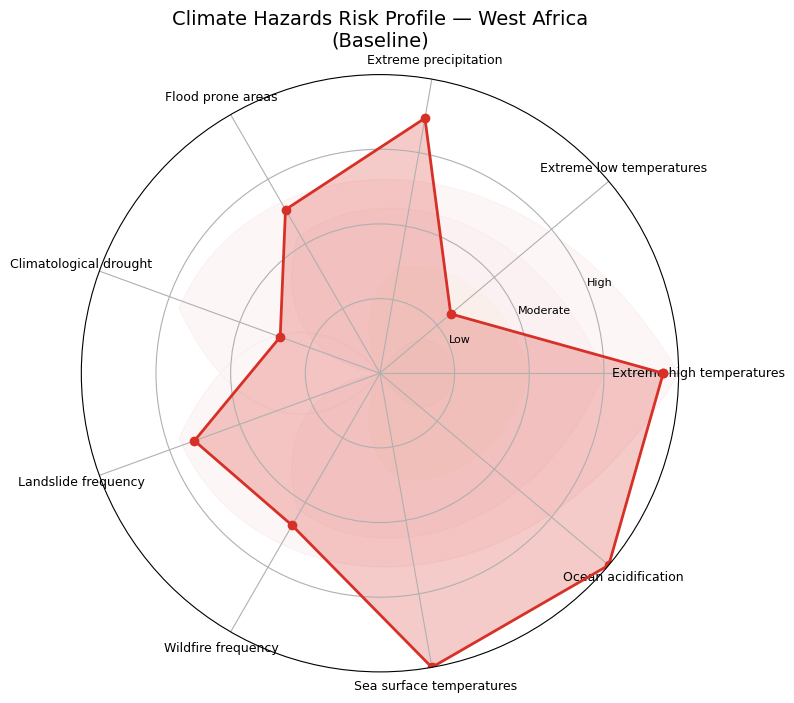

In [5]:
# Radar chart for hazard risk profile
if not df_hazards.empty and "mean" in df_hazards.columns:
    categories = df_hazards["caption"].tolist()
    values = df_hazards["mean"].fillna(0).tolist()
    N = len(categories)

    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    values_plot = values + values[:1]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Background risk zones
    for r, color, label in [(1, "#d4edda", "Low"), (2, "#fff3cd", "Moderate"),
                            (3, "#f8d7da", "High"), (4, "#f5c6cb", "Very High")]:
        circle = plt.Circle((0, 0), r, transform=ax.transData, color=color,
                            alpha=0.15, zorder=0)
        ax.add_patch(circle)

    ax.fill(angles, values_plot, alpha=0.25, color="#d73027")
    ax.plot(angles, values_plot, "o-", color="#d73027", linewidth=2, markersize=6)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=9)
    ax.set_ylim(0, 4)
    ax.set_yticks([1, 2, 3])
    ax.set_yticklabels(["Low", "Moderate", "High"], size=8)
    ax.set_title("Climate Hazards Risk Profile — West Africa\n(Baseline)", size=14, pad=20)

    plt.tight_layout()
    plt.show()
else:
    print("No data to plot. Check result structure above.")

## 5. Compare Climate Scenarios

Let's compare how hazard risks differ between the baseline and future projections under different emission scenarios.

In [6]:
# Run three scenarios
scenarios = {
    "Baseline": "Hazards_Baseline",
    "Near-Term RCP 2.6": "Hazards_Near_Term_RCP_2.6",
    "Near-Term RCP 8.5": "Hazards_Near_Term_RCP_8.5",
}

scenario_results = {}
for label, analysis_id in scenarios.items():
    print(f"Running {label}...")
    datacube = connection.datacube_from_process(
        process_id="crtb_analysis",
        analysis_id=analysis_id,
        geometry_type="geojson",
        geojson=west_africa_polygon,
    )
    scenario_results[label] = json.loads(datacube.save_result(format="JSON").download())

print("\nAll scenarios completed.")

Running Baseline...
Running Near-Term RCP 2.6...
Running Near-Term RCP 8.5...

All scenarios completed.


In [7]:
# Parse all scenarios
scenario_dfs = {}
for label, res in scenario_results.items():
    scenario_dfs[label] = parse_crtb_result(res)

# Find common indicators across scenarios
common_indicators = set(scenario_dfs["Baseline"]["indicator"].tolist())
for df in scenario_dfs.values():
    common_indicators &= set(df["indicator"].tolist())

print(f"Common indicators: {common_indicators}")

Common indicators: {'FROST', 'SPI', 'SSPH', 'TMAX', 'PMAX', 'SST'}


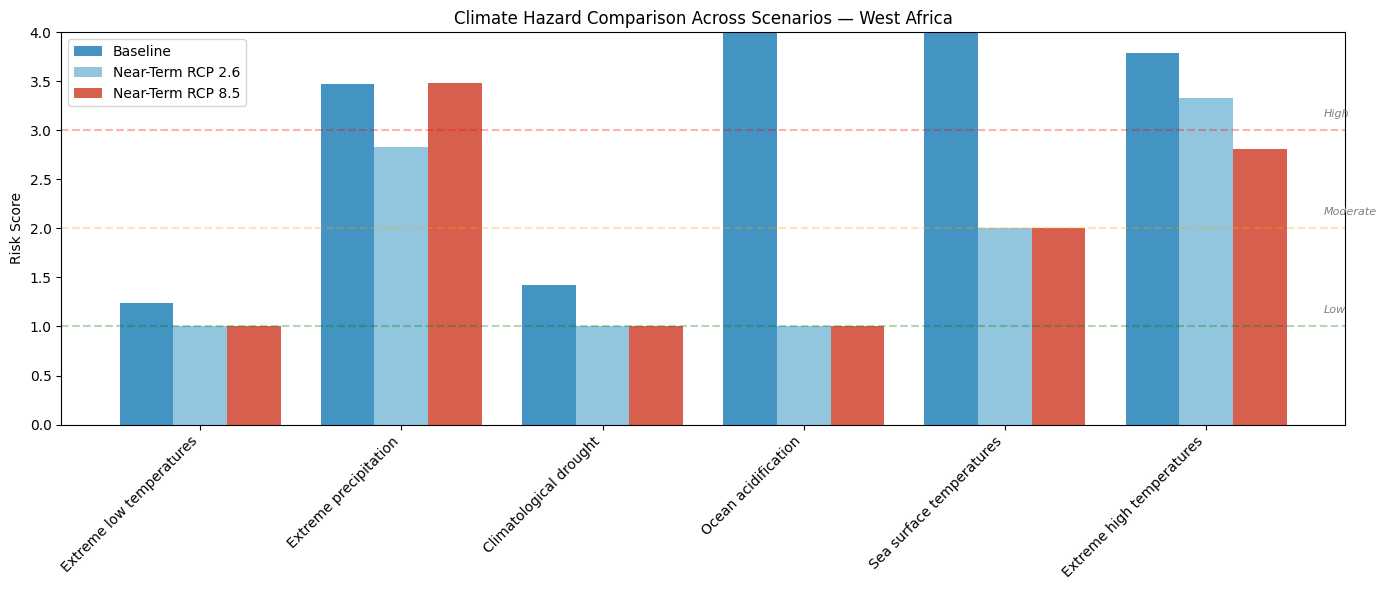

In [8]:
# Grouped bar chart comparing scenarios
if common_indicators:
    indicators = sorted(common_indicators)
    n_indicators = len(indicators)
    n_scenarios = len(scenario_dfs)
    x = np.arange(n_indicators)
    width = 0.8 / n_scenarios

    fig, ax = plt.subplots(figsize=(14, 6))
    colors = ["#4393c3", "#92c5de", "#d6604d"]

    for i, (label, df) in enumerate(scenario_dfs.items()):
        df_filtered = df[df["indicator"].isin(indicators)].set_index("indicator")
        values = [float(df_filtered.loc[ind, "mean"]) if ind in df_filtered.index
                  and df_filtered.loc[ind, "mean"] is not None else 0
                  for ind in indicators]
        ax.bar(x + i * width, values, width, label=label, color=colors[i % len(colors)])

    # Risk zone threshold lines + right-side labels
    zone_defs = [(1, "green", "Low"), (2, "orange", "Moderate"), (3, "red", "High")]
    for threshold, color, label in zone_defs:
        ax.axhline(y=threshold, color=color, linestyle="--", alpha=0.3)
        ax.text(n_indicators - 0.15, threshold + 0.12, label,
                va="bottom", ha="left", fontsize=8, fontstyle="italic", color="gray")

    # Get captions for x-axis labels
    captions = []
    for ind in indicators:
        for df in scenario_dfs.values():
            match = df[df["indicator"] == ind]
            if not match.empty:
                captions.append(match.iloc[0]["caption"])
                break
        else:
            captions.append(ind)

    ax.set_xticks(x + width * (n_scenarios - 1) / 2)
    ax.set_xticklabels(captions, rotation=45, ha="right")
    ax.set_ylabel("Risk Score")
    ax.set_title("Climate Hazard Comparison Across Scenarios — West Africa")
    ax.legend()
    ax.set_ylim(0, 4)
    plt.tight_layout()
    plt.show()

## 6. Full Risk Assessment

Let's assess all four dimensions of climate risk for a comprehensive picture.

In [9]:
# Run all four baseline dimensions
dimensions = {
    "Hazards": "Hazards_Baseline",
    "Vulnerability": "Vulnerability_Baseline",
    "Exposure": "Exposure_Baseline",
    "Adaptive Capacity": "adaptiveCapacity_Baseline",
}

dimension_results = {}
for label, analysis_id in dimensions.items():
    print(f"Running {label}...")
    datacube = connection.datacube_from_process(
        process_id="crtb_analysis",
        analysis_id=analysis_id,
        geometry_type="geojson",
        geojson=west_africa_polygon,
    )
    dimension_results[label] = json.loads(datacube.save_result(format="JSON").download())

print("\nAll dimensions assessed.")

Running Hazards...
Running Vulnerability...
Running Exposure...
Running Adaptive Capacity...

All dimensions assessed.


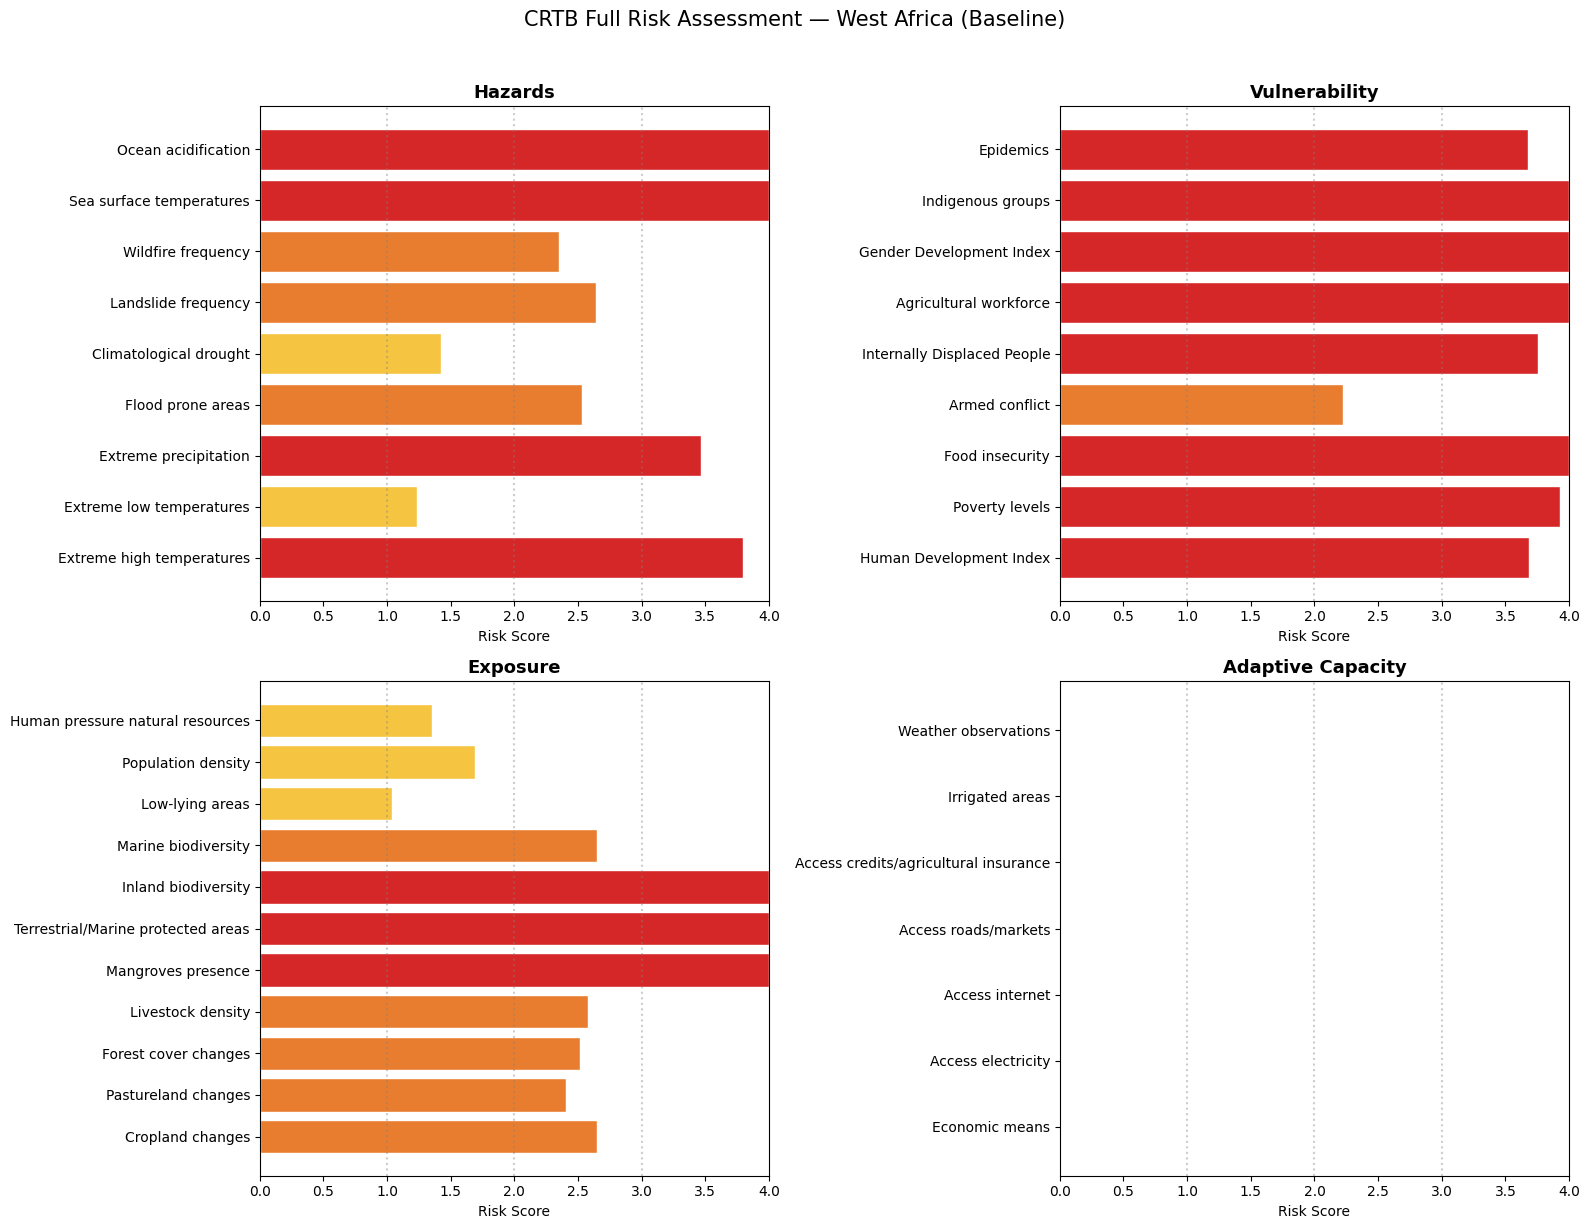

In [10]:
# Summary dashboard — one subplot per dimension
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

def risk_color(mean_val):
    """Map risk score to a green-yellow-orange-red gradient."""
    if mean_val is None or np.isnan(mean_val):
        return "#cccccc"
    if mean_val < 1:
        return "#2ca02c"
    elif mean_val < 2:
        return "#f5c542"
    elif mean_val < 3:
        return "#e87d2f"
    else:
        return "#d62728"

for idx, (label, res) in enumerate(dimension_results.items()):
    df = parse_crtb_result(res)
    ax = axes[idx]

    if not df.empty and "mean" in df.columns:
        means = df["mean"].fillna(0)
        colors = [risk_color(v) for v in df["mean"]]
        bars = ax.barh(df["caption"], means, color=colors, edgecolor="white")

        # Risk zone lines
        for threshold in [1, 2, 3]:
            ax.axvline(x=threshold, color="gray", linestyle=":", alpha=0.4)

        ax.set_xlim(0, 4)
        ax.set_xlabel("Risk Score")
    ax.set_title(label, fontsize=13, fontweight="bold")

fig.suptitle("CRTB Full Risk Assessment — West Africa (Baseline)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 7. Using Administrative Boundaries from GEE

Instead of providing a GeoJSON polygon, you can reference administrative boundaries from Google Earth Engine's GAUL dataset.

In [16]:
# Use a GEE Feature Collection for Egypt (GAUL admin level 2)
egypt_result = connection.datacube_from_process(
    process_id="crtb_analysis",
    analysis_id="Hazards_Baseline",
    geometry_type="feature_collection",
    geojson={
        "feature_collection_id": "FAO/GAUL_SIMPLIFIED_500m/2015/level2",
        "filters": [
            {
                "column": "ADM2_CODE",
                "filter": "eq",
                "value": 65896
            }
        ]
    },
)

egypt_hazards = json.loads(egypt_result.save_result(format="JSON").download())
print("Egypt district hazards:")
print(json.dumps(egypt_hazards, indent=2, default=str)[:2000])

Egypt district hazards:
{
  "gs://fao-gismgr-crtb-data-us/DATA/CRTB/MAPSET/HAZ-BI-2025/CRTB.HAZ-BI-2025.TMAX.tif": {
    "mean": 4,
    "answer": "Very high",
    "code": "TMAX",
    "caption": "Extreme high temperatures",
    "Question no": 1
  },
  "gs://fao-gismgr-crtb-data-us/DATA/CRTB/MAPSET/HAZ-BI-2025/CRTB.HAZ-BI-2025.FROST.tif": {
    "mean": 2,
    "answer": "Moderate",
    "code": "FROST",
    "caption": "Extreme low temperatures",
    "Question no": 2
  },
  "gs://fao-gismgr-crtb-data-us/DATA/CRTB/MAPSET/HAZ-BI-2025/CRTB.HAZ-BI-2025.PMAX.tif": {
    "mean": 1,
    "answer": "Low",
    "code": "PMAX",
    "caption": "Extreme precipitation",
    "Question no": 3
  },
  "gs://fao-gismgr-crtb-data-us/DATA/CRTB/MAPSET/HAZ-BI-2025/CRTB.HAZ-BI-2025.FLOOD.tif": {
    "mean": 1.0717603747036488,
    "answer": "Moderate",
    "code": "FLOOD",
    "caption": "Flood prone areas",
    "Question no": 4
  },
  "gs://fao-gismgr-crtb-data-us/DATA/CRTB/MAPSET/HAZ-BI-2025/CRTB.HAZ-BI-2025.SPI.

In [17]:
# Compare GeoJSON vs Feature Collection results
df_egypt = parse_crtb_result(egypt_hazards)

if not df_egypt.empty:
    print("\nEgypt District Risk Summary:")
    print(f"{'Indicator':<30} {'Risk Level':<15} {'Mean Score'}")
    print("-" * 60)
    for _, row in df_egypt.iterrows():
        caption = row['caption'] or "N/A"
        risk = row['risk'] or "N/A"
        mean = row['mean'] if row['mean'] is not None else "N/A"
        print(f"{caption:<30} {risk:<15} {mean}")


Egypt District Risk Summary:
Indicator                      Risk Level      Mean Score
------------------------------------------------------------
Extreme high temperatures      Very high       4.0
Extreme low temperatures       Moderate        2.0
Extreme precipitation          Low             1.0
Flood prone areas              Moderate        1.0717603747036488
Climatological drought         High            2.041874452802591
Landslide frequency            High            2.1250069087824444
Wildfire frequency             Moderate        1.4100294985250736
Sea surface temperatures       N/A             nan
Ocean acidification            N/A             nan


## Summary

In this tutorial, you learned how to:

1. **Run CRTB analyses** for hazards, vulnerability, exposure, and adaptive capacity
2. **Compare climate scenarios** (baseline vs. RCP 2.6 vs. RCP 8.5)
3. **Use GEE Feature Collections** for administrative boundary-based assessments
4. **Interpret risk classifications** (Low/Moderate/High/Very High)
5. **Visualize results** as radar charts, bar plots, and dashboard panels

### Available Analysis IDs

| ID | Category |
|---|---|
| `Hazards_Baseline` | Current hazards |
| `Hazards_Near_Term_RCP_2.6` | Near-term, low emissions |
| `Hazards_Near_Term_RCP_8.5` | Near-term, high emissions |
| `Hazards_Mid_Term_RCP_2.6` | Mid-term, low emissions |
| `Hazards_Mid_Term_RCP_8.5` | Mid-term, high emissions |
| `Vulnerability_Baseline` | Social vulnerability |
| `Exposure_Baseline` | Asset/ecosystem exposure |
| `adaptiveCapacity_Baseline` | Adaptive capacity |

### Next Steps

- **[Planting Recommendations](05_planting_recommendations.ipynb)** — Agricultural planning with PLAN-T
- Try combining CRTB results with vegetation monitoring from the [NDVI Time Series](02_ndvi_time_series.ipynb) tutorial